# Data Science Capstone — Adult Census Income: Data Preparation & EDA

In this notebook, I cover the data-preparation milestone for my capstone. It sets up a SQLite database, pulls the data back out, cleans it, and does exploratory data analysis. It runs top to bottom: setup, database load, inspect, clean, and EDA. The modeling comes in later milestones.

## The data

The dataset I chose for this project is the UCI Adult Census Income data, taken from the 1994 U.S. Census (about 32,500 rows and 15 raw columns). Each row is a person, and the underlying task in the later modeling milestone is to predict whether they earn more than $50K a year from their demographic, education, and job info.

- Target: income, which is >50K or <=50K. The classes are imbalanced (about 24% earn >50K), so accuracy on its own is misleading and I lead with PR-AUC instead.
- Predictors (12): age, workclass, education (as education_num), marital_status, occupation, relationship, race, sex, capital_gain, capital_loss, hours_per_week, and native_country (grouped into US vs non-US, with Unknown kept separate).
- I drop fnlwgt (final weight) because it is a census sampling weight, not something about the person, and the UCI docs say not to use it in the classifier.

## Research questions

The point of this project is not just to get a high accuracy score, but to understand what the model is doing and who it works for. I build everything around three questions, with the income classifier as the engine underneath. To motivate it, I frame the use case as a lender or screening tool that flags likely high earners, where the features driving the decision and fairness across groups matter more than raw accuracy.

- RQ1 (which features drive income): which features most strongly drive the >50K prediction, and does education level matter more than hours worked?
- RQ2 (is the model fair across nativity): does the model predict income equally well for US-born and foreign-born people, or does it systematically miss high earners in one group? This is the main question.
- RQ3 (does the extra complexity help): does a gradient-boosted model beat a logistic regression baseline on held-out PR-AUC? This is a secondary check.

This notebook is the groundwork. The EDA below already starts setting up RQ1 (education vs hours) and RQ2 (income rate by nativity), so the later modeling milestones have something concrete to build on.


<a id="sec-1"></a>

## 1. Setup


In [1]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install -U scikit-learn
%matplotlib inline

# small helper to make plot labels look nicer (education_num -> "Education (Years)")
def pretty(col):
    if col == "education_num":
        return "Education (Years)"
    return str(col).replace("_", " ").title()

    See /usr/share/doc/python3.12/README.venv for more information.
note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


<a id="sec-2"></a>

## 2. Database Setup & Load

For the milestone, the data goes into a SQLite database, and then the notebook pulls it back out and saves a CSV before any analysis. From here on the database is the source of truth.

### 2.1 Build the database

Load the raw CSV once and write it into adult.db. This is the file I commit to the repo under database/. The "?" missing values get turned into NaN when I load, so they're stored as SQL NULLs.

In [2]:
# build the SQLite database
# read the raw csv once and save it into adult.db as a table called "adult".
# this is the .db file I commit to the repo under database/
import sqlite3

raw = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)
conn = sqlite3.connect("adult.db")
raw.to_sql("adult", conn, if_exists="replace", index=False)
conn.close()

print("Saved adult.db with", len(raw), "rows")

Saved adult.db with 32561 rows


### 2.2 Pull from the database and save a CSV

Read the data back out of the database with a SQL SELECT, then save a CSV copy. Everything after this runs on this df, which is the same as reading the raw CSV directly.

In [3]:
# pull the data back out of the database and save a csv copy.
# the "?" values became NULLs when I built the db, so they come back as NaN
conn = sqlite3.connect("adult.db")
df = pd.read_sql("SELECT * FROM adult", conn)
conn.close()

df.to_csv("adult_pulled.csv", index=False)   # csv copy of the pulled data
print("Shape:", df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<a id="sec-3"></a>

## 3. Initial Data Inspection

A quick look at the raw data before cleaning it.

In [4]:
# how many rows and columns
df.shape

(32561, 15)

In [5]:
# column types and non-null counts (missing values show up here)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
# summary stats for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [7]:
# data type of each column
df.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object

<a id="sec-4"></a>

## 4. Data Cleaning

The order of these steps matters, so I run them like this:

1. Check missing values, duplicates, and the target balance first (a "before" snapshot).
2. Fill missing categorical values with "Unknown" (before the rename, so the dotted names still work).
3. Drop duplicates while fnlwgt is still there, so only the 24 real duplicates get removed.
4. Drop fnlwgt and education.
5. Rename the columns (dots to underscores).

Steps 3 and 4 have to be in this order. fnlwgt is a sampling weight that's almost unique per row, so it keeps similar people looking different. If I dropped it first and then removed duplicates, about 3,200 different people would collapse into fake duplicates.

In [8]:
# check missing values, duplicates, and the target balance before cleaning
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nIncome counts:")
print(df["income"].value_counts())
print(df["income"].value_counts(normalize=True).round(3))

Missing values per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Duplicate rows: 24

Income counts:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


In [9]:
# fill the missing categorical values with "Unknown" instead of dropping the rows.
# do this before the rename, so the columns still have their dotted names
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].fillna("Unknown")

# check none are left
print(df[["workclass", "occupation", "native.country"]].isnull().sum())

workclass         0
occupation        0
native.country    0
dtype: int64


In [10]:
# drop the exact duplicate rows.
# do this while fnlwgt is still here, otherwise a lot of different people
# would look like duplicates
before = len(df)
df = df.drop_duplicates()
print("Rows before:", before)
print("Rows after:", len(df))
print("Duplicates removed:", before - len(df))

Rows before: 32561
Rows after: 32537
Duplicates removed: 24


In [11]:
# drop fnlwgt (a survey sampling weight, not about the person) and
# education (redundant with education_num)
df = df.drop(columns=["fnlwgt", "education"])
print("Shape:", df.shape)

Shape: (32537, 13)


In [12]:
# rename columns so the dots become underscores
df.columns = df.columns.str.replace(".", "_", regex=False)
print(list(df.columns))

['age', 'workclass', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


In [13]:
# check the cleaned data: no missing values, right shape and types
df.info()

<class 'pandas.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  str  
 2   education_num   32537 non-null  int64
 3   marital_status  32537 non-null  str  
 4   occupation      32537 non-null  str  
 5   relationship    32537 non-null  str  
 6   race            32537 non-null  str  
 7   sex             32537 non-null  str  
 8   capital_gain    32537 non-null  int64
 9   capital_loss    32537 non-null  int64
 10  hours_per_week  32537 non-null  int64
 11  native_country  32537 non-null  str  
 12  income          32537 non-null  str  
dtypes: int64(5), str(8)
memory usage: 3.5 MB


<a id="sec-5"></a>

## 5. Exploratory Data Analysis (EDA)

All the plots below use the cleaned data with the underscore column names.

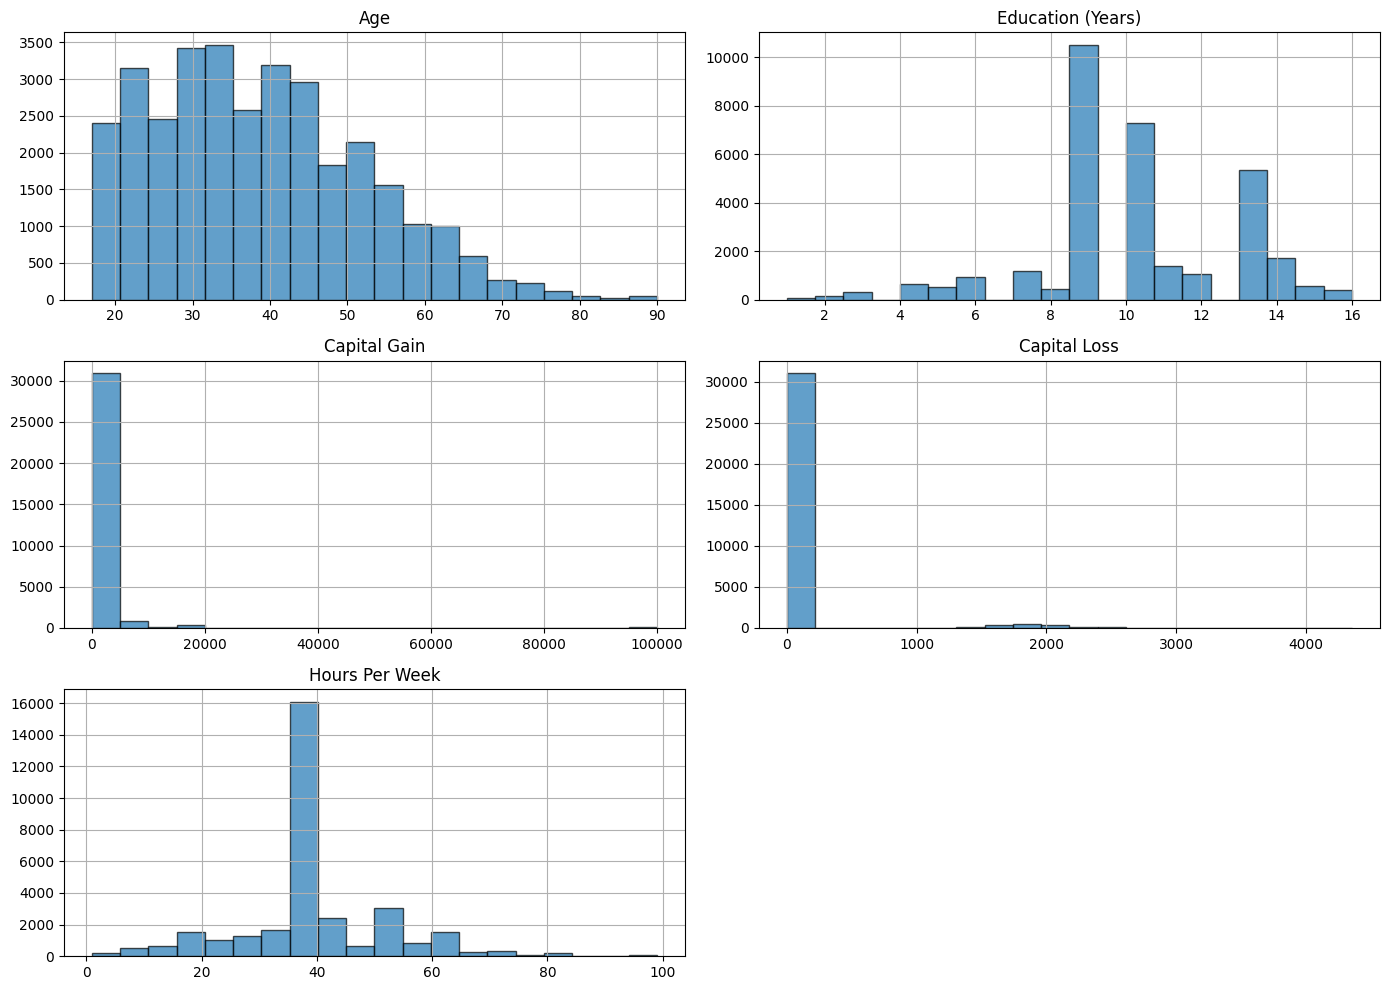

In [14]:
# histograms of the numeric columns to see their distributions
axes = df.hist(figsize=(14, 10), bins=20, edgecolor="black", alpha=0.7)
for ax in axes.flatten():
    if ax.get_title():
        ax.set_title(pretty(ax.get_title()))
plt.tight_layout()
plt.show()

These are the distributions of the numeric columns. Capital gain and capital loss are very right-skewed: almost everyone is at 0 with a few large values, so those panels look like one tall bar at zero. Hours per week clusters hard at 40. Age is spread out and roughly bell-shaped (mean around 38.6), and education is discrete and centered around 10 years. The heavy skew is one reason scaling happens inside the model pipeline.

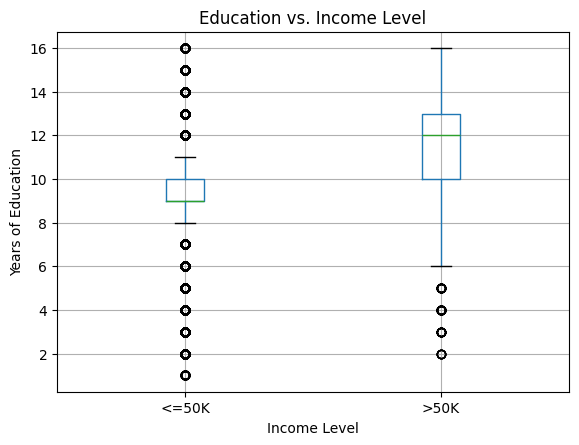

In [15]:
# boxplot of education level for each income class
df.boxplot(column="education_num", by="income")
plt.xlabel("Income Level")
plt.ylabel("Years of Education")
plt.title("Education vs. Income Level")
plt.suptitle("")   # drop the extra title pandas adds
plt.show()

Each box is the middle 50% of the data, the line is the median, and the dots are outliers. The >50K group sits higher on the education scale than the <=50K group, so years of education helps separate the two classes. There's still a lot of overlap though, which is why education alone can't predict income perfectly.

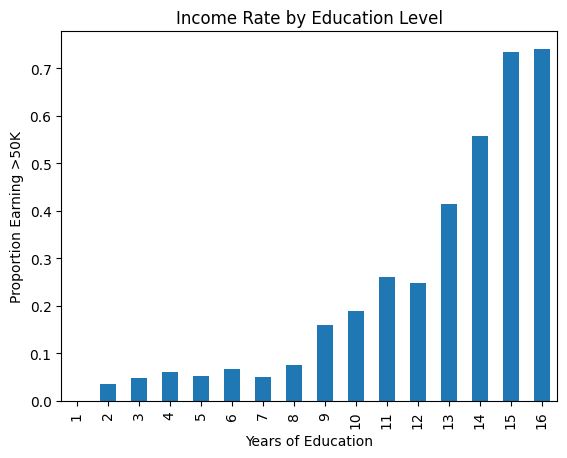

In [16]:
# share of people earning >50K at each education level
rate = df.groupby("education_num")["income"].apply(lambda s: (s == ">50K").mean())
rate.plot(kind="bar")
plt.xlabel("Years of Education")
plt.ylabel("Proportion Earning >50K")
plt.title("Income Rate by Education Level")
plt.show()

Each bar is the share of people at that education level who earn >50K. The bars go up steadily as education increases, which is a nice clean trend that a linear model like logistic regression can use directly. The bars at the rarest education levels are jumpier because they're based on fewer people.

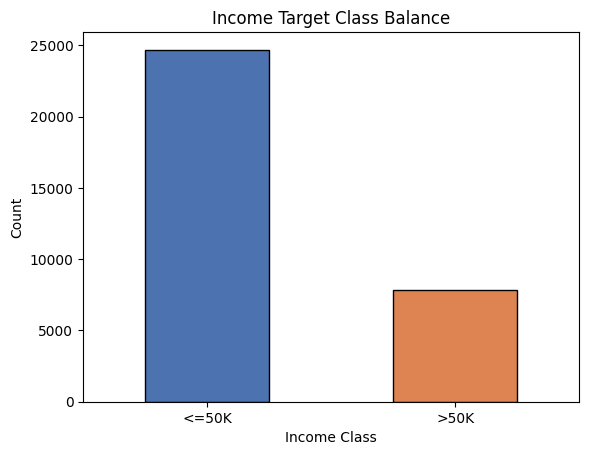

In [17]:
# target class balance (about 76% <=50K vs 24% >50K, so it's imbalanced)
df["income"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], edgecolor="black")
plt.title("Income Target Class Balance")
plt.ylabel("Count")
plt.xlabel("Income Class")
plt.xticks(rotation=0)
plt.show()

This is the class balance of the target: about 75.9% <=50K vs 24.1% >50K. Two things follow from this. First, plain accuracy is misleading, since always predicting "nobody earns >50K" already gets about 76%, so I lead with PR-AUC and recall instead. Second, the pipeline uses oversampling to help with the imbalance. That 24.1% is also the no-skill floor that every model's PR-AUC gets compared to.

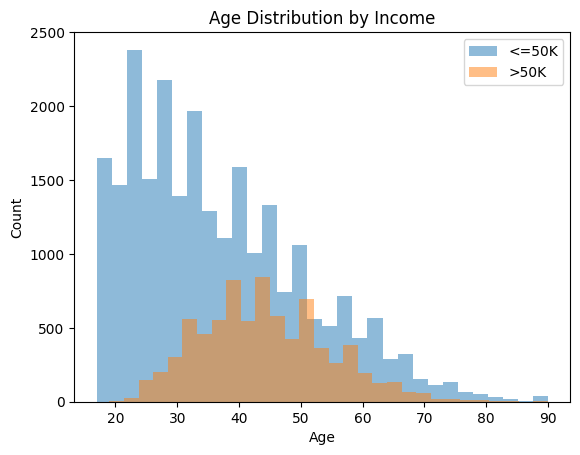

In [18]:
# age distribution for each income class
df[df["income"] == "<=50K"]["age"].plot(kind="hist", bins=30, alpha=0.5, label="<=50K")
df[df["income"] == ">50K"]["age"].plot(kind="hist", bins=30, alpha=0.5, label=">50K")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.title("Age Distribution by Income")
plt.show()

These are two overlaid histograms, one per income class. The >50K group leans toward middle age while the <=50K group skews younger. The relationship isn't linear (the high-income share rises into middle age and then drops for the oldest ages), which tree and network models can pick up better than a linear model.

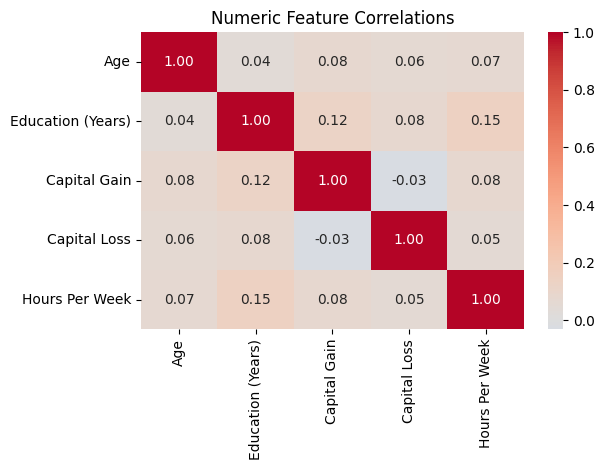

In [19]:
# correlation heatmap of the numeric features
num = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
labels = [pretty(c) for c in num]
sns.heatmap(df[num].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f",
            xticklabels=labels, yticklabels=labels)
plt.title("Numeric Feature Correlations")
plt.tight_layout()
plt.show()

Each cell is the correlation between two numeric features, from -1 to +1. I'm mainly checking for strongly correlated pairs (say |r| > 0.7) that could make the logistic regression coefficients unstable. All the off-diagonal values here are small, so there's no real multicollinearity problem and I don't need to drop any of the numeric features.

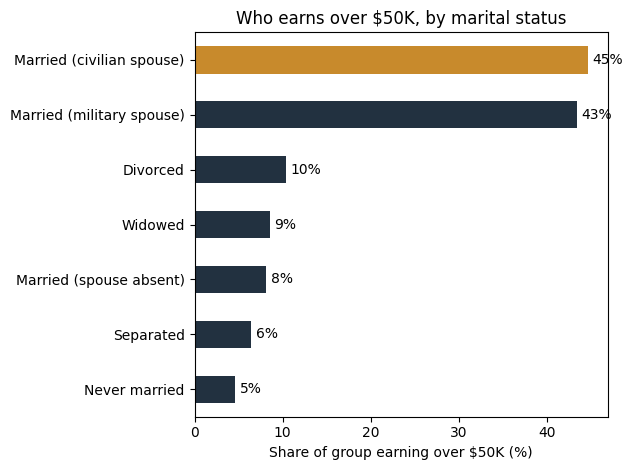

In [20]:
# income rate by marital status, with clearer category labels
# map the raw dataset codes to plain-English labels so the y-axis is easy to read
label_map = {
    "Married-civ-spouse": "Married (civilian spouse)",
    "Married-AF-spouse": "Married (military spouse)",
    "Married-spouse-absent": "Married (spouse absent)",
    "Never-married": "Never married",
    "Divorced": "Divorced",
    "Separated": "Separated",
    "Widowed": "Widowed",
}
rate = df.groupby("marital_status")["income"].apply(lambda s: (s == ">50K").mean()).sort_values()
rate.index = [label_map.get(i, i) for i in rate.index]

# color all bars the same, then highlight the top group so it stands out
colors = ["#223140"] * len(rate)
colors[int(rate.values.argmax())] = "#C88A2C"

ax = (rate * 100).plot(kind="barh", color=colors)
ax.set_xlabel("Share of group earning over $50K (%)")
ax.set_ylabel("")
ax.set_title("Who earns over $50K, by marital status")

# put the percentage at the end of each bar
for i, v in enumerate(rate.values * 100):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center")

plt.tight_layout()
plt.show()


These bars are the share of each marital-status group that earns over $50K, sorted. The spread is big: married (civilian spouse) people are far above the never-married, separated, and divorced groups, so marital status is one of the strongest single predictors in the data. I relabeled the raw dataset codes (for example "Married-civ-spouse") to plain-English labels so the chart is easy to read at a glance.

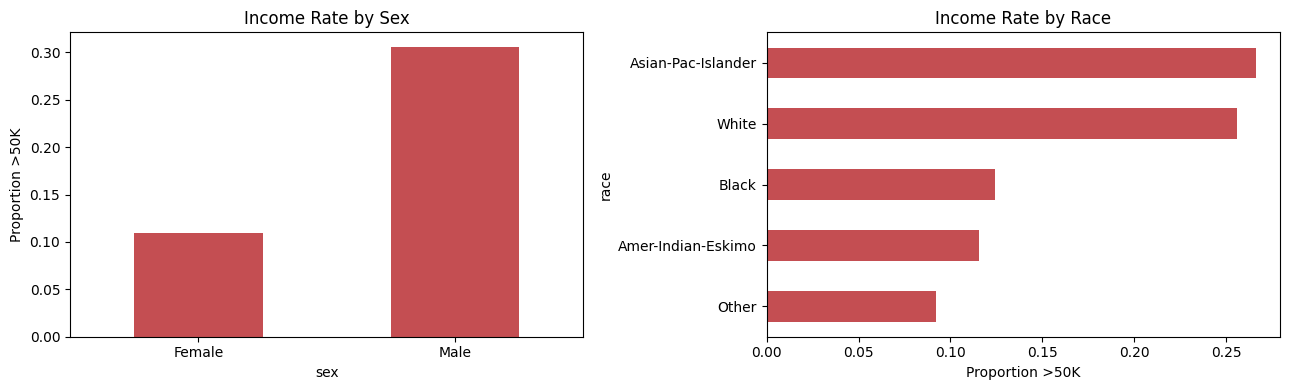

In [21]:
# >50K rate by sex and race -- how the income rate varies across these two features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sex_rate = df.groupby("sex")["income"].apply(lambda s: (s == ">50K").mean())
sex_rate.plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Income Rate by Sex")
axes[0].set_ylabel("Proportion >50K")
axes[0].tick_params(axis="x", rotation=0)

race_rate = df.groupby("race")["income"].apply(lambda s: (s == ">50K").mean())
race_rate.sort_values().plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("Income Rate by Race")
axes[1].set_xlabel("Proportion >50K")

plt.tight_layout()
plt.show()

These are the >50K rates across sex and race in the data. Men earn >50K at a higher rate than women, and the rate varies across race groups too. Both are categorical features the model can use, so it's worth seeing how strongly they line up with the target before modeling.

<a id="sec-5-7"></a>

### 5.7 Income by nativity (sets up the fairness question)

native_country is about 90% United States, so for the fairness audit (RQ2) I group it into US vs non-US and keep Unknown as its own bucket rather than forcing it onto one side. Before any modeling, I want to see how the >50K rate itself differs across these groups, since that is the gap the model will later be audited against.

Group sizes:
native_region
US         29153
non-US      2802
Unknown      582
Name: count, dtype: int64

>50K rate by region:
native_region
US         0.246
Unknown    0.251
non-US     0.187
Name: income, dtype: float64


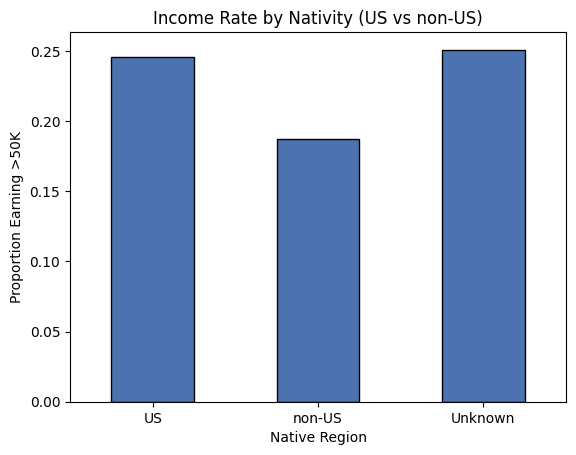

In [22]:
# group native_country into US vs non-US (Unknown kept separate) to set up the fairness question
df["native_region"] = df["native_country"].apply(
    lambda c: "US" if c == "United-States" else ("Unknown" if c == "Unknown" else "non-US")
)

# group sizes and the >50K rate for each region
region_n = df["native_region"].value_counts()
region_rate = df.groupby("native_region")["income"].apply(lambda s: (s == ">50K").mean())

print("Group sizes:")
print(region_n)
print("\n>50K rate by region:")
print(region_rate.round(3))

region_rate.reindex(["US", "non-US", "Unknown"]).plot(
    kind="bar", color="#4C72B0", edgecolor="black")
plt.ylabel("Proportion Earning >50K")
plt.xlabel("Native Region")
plt.title("Income Rate by Nativity (US vs non-US)")
plt.xticks(rotation=0)
plt.show()

The US-born group has a higher >50K rate than the non-US group in the raw data. That base-rate gap is exactly why RQ2 matters: if the model just learns this gap, it can end up missing real high earners among foreign-born people (a higher false negative rate for that group). I am not testing that here, this is only the setup, but it tells the later fairness audit where to look and gives me the two groups I will split the error rates by.

### 5.7b Income split: US-born vs foreign-born

The chart above shows only the >50K share. To make the US-born vs foreign-born comparison easy to read, here is the full income split for each group, showing both who earns over $50K and who earns $50K or less. This is the version I use in the presentation. Unknown-country rows are left out here so the comparison is strictly US-born vs foreign-born.

income        >50K  <=50K
nativity                 
US-born       24.6   75.4
Foreign-born  18.7   81.3


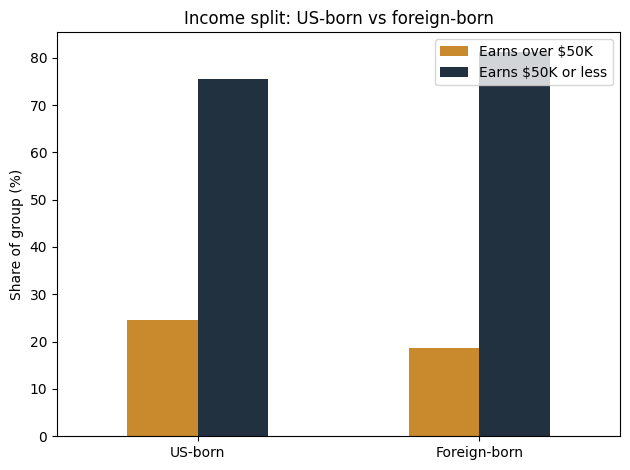

In [23]:
# full income split (>50K and <=50K) for US-born vs foreign-born
sub = df[df["native_region"].isin(["US", "non-US"])].copy()
sub["nativity"] = sub["native_region"].map({"US": "US-born", "non-US": "Foreign-born"})

split = (sub.groupby("nativity")["income"].value_counts(normalize=True)
         .unstack().reindex(["US-born", "Foreign-born"]) * 100)
print(split[[">50K", "<=50K"]].round(1))

split[[">50K", "<=50K"]].plot(kind="bar", color=["#C88A2C", "#223140"])
plt.ylabel("Share of group (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.title("Income split: US-born vs foreign-born")
plt.legend(["Earns over $50K", "Earns $50K or less"])
plt.tight_layout()
plt.show()

US-born people earn over $50K at a higher rate than foreign-born people (about 25% vs 19% in this data). That base-rate gap is exactly what the fairness audit in RQ2 checks: if the model just learns this gap, it can end up missing real high earners among foreign-born people. This chart is only the setup, not the audit itself.

<a id="sec-5-8"></a>

### 5.8 Education vs hours worked (which driver matters more)

RQ1 asks whether education level drives the >50K prediction more than hours worked. I cannot answer that with EDA alone (that needs feature importance on the trained model), but I can look at how cleanly each feature separates the classes on its own, which is a first hint.

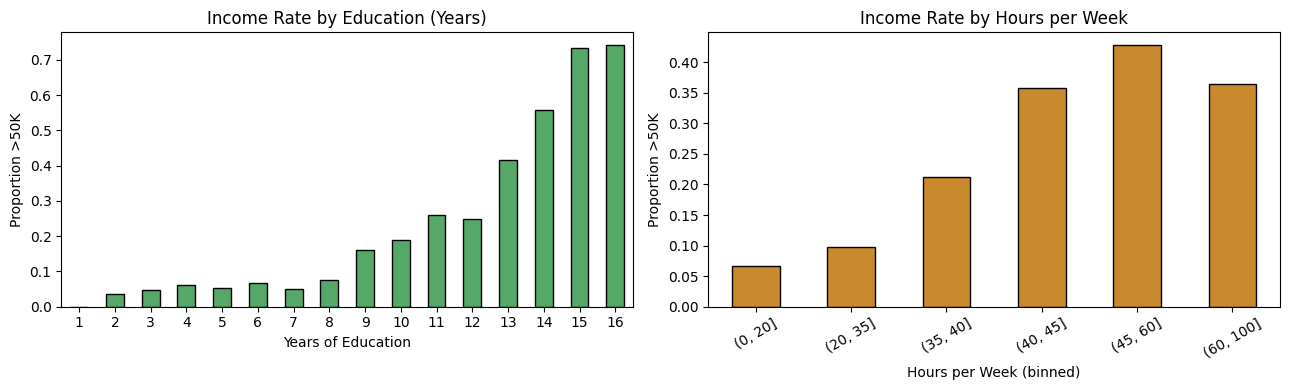

In [24]:
# which separates the classes better on its own: education or hours worked?
# bin hours into ranges, then compare the >50K rate across education levels vs hours bins
hour_bins = pd.cut(df["hours_per_week"], bins=[0, 20, 35, 40, 45, 60, 100])
hours_rate = df.groupby(hour_bins, observed=True)["income"].apply(lambda s: (s == ">50K").mean())
edu_rate = df.groupby("education_num")["income"].apply(lambda s: (s == ">50K").mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_rate.plot(kind="bar", ax=axes[0], color="#55A868", edgecolor="black")
axes[0].set_title("Income Rate by Education (Years)")
axes[0].set_xlabel("Years of Education")
axes[0].set_ylabel("Proportion >50K")
axes[0].tick_params(axis="x", rotation=0)

hours_rate.plot(kind="bar", ax=axes[1], color="#C88A2C", edgecolor="black")
axes[1].set_title("Income Rate by Hours per Week")
axes[1].set_xlabel("Hours per Week (binned)")
axes[1].set_ylabel("Proportion >50K")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Education shows a steady, clean climb in the >50K rate from the lowest to the highest levels. Hours worked also trends up, but it flattens out and is noisier at the extremes (a few people working very long hours are not reliably high earners). This is only a one-feature-at-a-time view and does not control for the fact that education and hours are correlated with other features, so it is not the final answer to RQ1. It does give me a testable expectation to bring into the modeling milestone: I expect education to come out as the stronger driver once I measure permutation importance and compare coefficients.

### How I Used LLM for This Assignment

I used LLMs to help me find the dataset for this project as well as develop a good research question and fine tune how I would properly test my question using different models. I also used LLMs to help me troubleshoot different bugs in my code and develop some explanations for the outputs I got so I could correctly interpret my results from the visuals I made. Finally, I used LLMs to compare what I had completed for the assignment against what was required in the instructions to make sure I was not missing anything needed to be submitted. 